In [1]:
"""
PowerGuardian AI - Electricity Theft Detection & Grid Intelligence System
A machine learning framework for detecting, classifying, and predicting electricity theft 
using time-series analytics, anomaly detection, and grid intelligence models.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score, roc_auc_score, roc_curve
)

from scipy import stats
import warnings
import joblib
import os
from datetime import datetime

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Create project directories
os.makedirs('models', exist_ok=True)       # saved ML models
os.makedirs('processed', exist_ok=True)    # cleaned datasets
os.makedirs('visualizations', exist_ok=True)  # plots & charts

print("="*90)
print("POWERGUARDIAN AI - ELECTRICITY THEFT DETECTION SYSTEM")
print("="*90)
print(f"\nAnalysis started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")


POWERGUARDIAN AI - ELECTRICITY THEFT DETECTION SYSTEM

Analysis started: 2025-12-02 15:39:01



In [2]:
# ============================================================================
# DATA LOADING AND EXPLORATION
# ============================================================================
print("\n" + "="*80)
print("DATA LOADING AND EXPLORATION")
print("="*80)

file_path = "electricity_consumption_dataset.xlsx"

# Load raw file with no header first
df_raw = pd.read_excel(file_path, header=None)

# Extract real header at row index 9
header_row = 9
df = pd.read_excel(file_path, header=header_row)

# Remove metadata rows above header
df = df[df.iloc[:, 0].notna()].reset_index(drop=True)

print(f"\nDataset shape: {df.shape[0]} samples, {df.shape[1]} features")

print("\nFirst 10 rows:")
print(df.head(10))

print("\n\nDataset information:")
print(df.info())

print("\n\nStatistical summary:")
print(df.describe(include='all'))



DATA LOADING AND EXPLORATION

Dataset shape: 19584 samples, 36 features

First 10 rows:
   Sr. No.  CO2 Emissions  Population (in thousands)  Year  Month State  \
0        1          109.6                     4050.0  1990      1    AL   
1        2           50.8                     2357.0  1990      1    AR   
2        3           63.1                     3684.0  1990      1    AZ   
3        4          360.2                    29960.0  1990      1    CA   
4        5           66.5                     3308.0  1990      1    CO   
5        6           40.4                     3292.0  1990      1    CT   
6        7           18.0                      670.0  1990      1    DE   
7        8          187.5                    13033.0  1990      1    FL   
8        9          139.0                     6513.0  1990      1    GA   
9       10           63.5                     2781.0  1990      1    IA   

   Cooling Degree Days  Palmer Drought Severity Index  Palmer Z-index  \
0           

In [3]:
# ============================================================================
# MISSING DATA ANALYSIS
# ============================================================================
print("\n" + "="*80)
print("MISSING DATA ANALYSIS")
print("="*80)

missing_counts = df.isnull().sum()
missing_percent = (missing_counts / len(df)) * 100

missing_data = pd.DataFrame({
    'Column': missing_counts.index,
    'Missing': missing_counts.values,
    'Percent': missing_percent.values
})

missing_data = missing_data[missing_data['Missing'] > 0].sort_values('Missing', ascending=False)

if len(missing_data) > 0:
    print("\nMissing values detected:")
    print(missing_data.to_string(index=False))

    # Visualize missing data
    plt.figure(figsize=(12, 6))
    plt.bar(missing_data['Column'], missing_data['Percent'], edgecolor='black')
    plt.title('Missing Data Percentage by Column', fontsize=14, fontweight='bold')
    plt.xlabel('Column')
    plt.ylabel('Missing (%)')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Handle missing values
    print("\nHandling missing values...")
    for col in missing_data['Column']:
        if df[col].dtype in ['float64', 'int64']:
            median_val = df[col].median()
            df[col].fillna(median_val, inplace=True)
            print(f"  {col}: filled with median ({median_val:.2f})")
        else:
            mode_val = df[col].mode()[0]
            df[col].fillna(mode_val, inplace=True)
            print(f"  {col}: filled with mode ({mode_val})")

else:
    print("\nNo missing values found.")


MISSING DATA ANALYSIS

No missing values found.


In [4]:
# ============================================================================
# TIME-SERIES ALIGNMENT (Year → Month → Timestamp)
# ============================================================================
print("\n" + "="*80)
print("TIME-SERIES ALIGNMENT")
print("="*80)

# Create proper datetime
df["Timestamp"] = pd.to_datetime(
    df["Year"].astype(str) + "-" + df["Month"].astype(str) + "-01"
)

# Sort chronologically
df = df.sort_values("Timestamp").reset_index(drop=True)

print("\nTimestamp format fixed. Sample:")
print(df[["Year", "Month", "Timestamp"]].head())



TIME-SERIES ALIGNMENT

Timestamp format fixed. Sample:
   Year  Month  Timestamp
0  1990      1 1990-01-01
1  1990      1 1990-01-01
2  1990      1 1990-01-01
3  1990      1 1990-01-01
4  1990      1 1990-01-01


In [5]:
# Clean column names: strip spaces and special characters
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace('\n', '', regex=True)
df.columns = df.columns.str.replace(r'[^A-Za-z0-9 _]+', '', regex=True)

print(df.columns.tolist())  # check cleaned names


['Sr No', 'CO2 Emissions', 'Population in thousands', 'Year', 'Month', 'State', 'Cooling Degree Days', 'Palmer Drought Severity Index', 'Palmer Zindex', 'Area Percentage Urban Cluster', 'Area Percentage Water', 'Area Percentage Very Warm', 'Area Percentage Very Cold', 'Primary Energy Stock Change', 'Solar Net Generation by All Sectors', 'Solar Generation at SmallScale by Commercial Sector', 'Anomaly Level', 'Climate Category', 'Renewable Energy Consumption Geothermal', 'Renewable Energy Consumption Hydropower', 'Renewable Energy Consumption Solar', 'Renewable Energy Consumption Wind', 'Total Energy Consumption per Capita', 'Climate Region', 'Precipitation Anomaly', 'Area Percentage Cold Highs', 'Area Percentage Cold Lows', 'Average Temperature Spring', 'Average Temperature Summer', 'Average Temperature Fall', 'GDP Percentage Change', 'Gross Private Domestic Investment Percentage Change', 'Government Expenditure and Investment Percentage Change', 'Residential Electricity Consumption', '

In [6]:
# ============================================================================
# FEATURE ENGINEERING FOR ELECTRICITY THEFT DETECTION
# ============================================================================
print("\n" + "="*80)
print("FEATURE ENGINEERING FOR THEFT DETECTION")
print("="*80)

# -----------------------------------------------------------
# 1. TOTAL CONSUMPTION (Core variable)
# -----------------------------------------------------------
df["Total_Electricity_Consumption"] = (
    df["Residential Electricity Consumption"] +
    df["Commercial Electricity Consumption"] +
    df["Industrial Electricity Consumption"]
)

# -----------------------------------------------------------
# 2. ROLLING AVERAGES (3M, 6M, 12M)
# -----------------------------------------------------------
df["Rolling_3M"]  = df.groupby("State")["Total_Electricity_Consumption"].transform(lambda x: x.rolling(3).mean())
df["Rolling_6M"]  = df.groupby("State")["Total_Electricity_Consumption"].transform(lambda x: x.rolling(6).mean())
df["Rolling_12M"] = df.groupby("State")["Total_Electricity_Consumption"].transform(lambda x: x.rolling(12).mean())

# -----------------------------------------------------------
# 3. HOURLY, DAILY, WEEKLY CONSUMPTION  (Proxy features)
#    NOTE: Since dataset is MONTHLY, we create normalized per-day/hour estimates
# -----------------------------------------------------------
days_in_month = df["Month"].map({
    1:31, 2:28, 3:31, 4:30, 5:31, 6:30,
    7:31, 8:31, 9:30, 10:31, 11:30, 12:31
})

df["Daily_Consumption"]  = df["Total_Electricity_Consumption"] / days_in_month
df["Hourly_Consumption"] = df["Daily_Consumption"] / 24
df["Weekly_Consumption"] = df["Daily_Consumption"] * 7

# -----------------------------------------------------------
# 4. TEMPERATURE-ADJUSTED CONSUMPTION (Consumption vs Weather)
# -----------------------------------------------------------
df["Temp_Adjusted_Consumption"] = (
    df["Total_Electricity_Consumption"] /
    (df["Average Temperature Spring"] + df["Average Temperature Summer"] + df["Average Temperature Fall"])
)

# Cooling Degree Days (CDD) influence
df["CDD_Impact"] = df["Total_Electricity_Consumption"] / (df["Cooling Degree Days"] + 1)

# -----------------------------------------------------------
# 5. HOLIDAY EFFECT (Proxy Feature)
#    We create a binary feature for months with major U.S. holidays
# -----------------------------------------------------------
holiday_months = [11, 12, 7]  # Thanksgiving, Christmas, July 4th
df["Holiday_Month"] = df["Month"].apply(lambda m: 1 if m in holiday_months else 0)

# -----------------------------------------------------------
# 6. VOLTAGE DROP (Synthetic Proxy)
#    *Since dataset lacks voltage*, we simulate based on anomalies
# -----------------------------------------------------------
df["Voltage_Drop_Estimate"] = (
    (df["Cooling Degree Days"] + df["Area Percentage Very Warm"]) /
    (df["Total_Electricity_Consumption"] + 1)
)

# -----------------------------------------------------------
# 7. TRANSFORMER–METER IMBALANCE (Synthetic Proxy)
#    Used to approximate theft likelihood
# -----------------------------------------------------------
df["Grid_Imbalance_Index"] = (
    df["Residential Electricity Consumption"] / 
    (df["Industrial Electricity Consumption"] + 1)
)

# Higher imbalance → possible theft
df["Imbalance_Anomaly_Score"] = (
    (df["Grid_Imbalance_Index"] - df["Grid_Imbalance_Index"].mean()) /
    df["Grid_Imbalance_Index"].std()
)

# -----------------------------------------------------------
# 8. PERCENTAGE CHANGE SIGNALS
# -----------------------------------------------------------
df["Pct_Change"] = df.groupby("State")["Total_Electricity_Consumption"].pct_change()

# -----------------------------------------------------------
# 9. Z-SCORE CONSUMPTION ANOMALY
# -----------------------------------------------------------
df["Z_Score_Consumption"] = df.groupby("State")["Total_Electricity_Consumption"].transform(
    lambda x: (x - x.mean()) / (x.std() + 1e-9)
)

print("\nFeature engineering complete.")
print(df.head())


FEATURE ENGINEERING FOR THEFT DETECTION

Feature engineering complete.
   Sr No  CO2 Emissions  Population in thousands  Year  Month State  \
0      1          109.6                   4050.0  1990      1    AL   
1     27           32.8                   1582.0  1990      1    NE   
2     28           14.6                   1112.0  1990      1    NH   
3     29          109.9                   7763.0  1990      1    NJ   
4     30           52.8                   1522.0  1990      1    NM   

   Cooling Degree Days  Palmer Drought Severity Index  Palmer Zindex  \
0                   21                           3.84           2.79   
1                    0                          -3.69          -0.59   
2                    0                           1.62           1.41   
3                    0                          -0.63           0.86   
4                    0                          -2.52          -0.04   

   Area Percentage Urban Cluster  ...  Hourly_Consumption  Weekly_Co

In [7]:
# Count missing values per column
missing_counts = df.isnull().sum()

# Percentage of missing values
missing_percent = (missing_counts / len(df)) * 100

# Show only columns with missing values
missing_data = pd.DataFrame({
    'Column': missing_counts.index,
    'Missing': missing_counts.values,
    'Percent': missing_percent.values
})
missing_data = missing_data[missing_data['Missing'] > 0].sort_values('Missing', ascending=False)

print("\nMissing values detected:")
print(missing_data.to_string(index=False))



Missing values detected:
     Column  Missing  Percent
Rolling_12M      528 2.696078
 Rolling_6M      240 1.225490
 Rolling_3M       96 0.490196
 Pct_Change       48 0.245098


In [8]:
# Fill rolling averages with the first available value
df["Rolling_3M"].fillna(df["Total_Electricity_Consumption"], inplace=True)
df["Rolling_6M"].fillna(df["Total_Electricity_Consumption"], inplace=True)
df["Rolling_12M"].fillna(df["Total_Electricity_Consumption"], inplace=True)

# Fill percentage change with 0 (no change for first row)
df["Pct_Change"].fillna(0, inplace=True)


In [9]:
# ============================================================================
# ELECTRICITY REFERENCE RANGES
# ============================================================================
print("\n" + "="*80)
print("ELECTRICITY REFERENCE RANGES")
print("="*80)

electricity_ranges = {
    'Residential Consumption (kWh)': {
        'normal': (100, 1000),   # typical monthly household range
        'suspicious_low': (0, 99),
        'suspicious_high': (1001, 5000)
    },
    'Commercial Consumption (kWh)': {
        'normal': (1000, 20000),
        'suspicious_low': (0, 999),
        'suspicious_high': (20001, 100000)
    },
    'Industrial Consumption (kWh)': {
        'normal': (20000, 500000),
        'suspicious_low': (0, 19999),
        'suspicious_high': (500001, 2000000)
    },
    'Voltage Drop Estimate': {
        'normal': (0, 0.2),      # <20% drop is acceptable
        'critical': (0.21, 1.0)  # >20% drop may indicate theft or overload
    },
    'Grid Imbalance Index': {
        'balanced': (0.2, 5.0),  # ratio of residential vs industrial
        'anomalous': (5.01, 50.0)
    },
    'Pct_Change': {
        'stable': (-0.2, 0.2),   # ±20% month-to-month change
        'suspicious_drop': (-1.0, -0.21),
        'suspicious_spike': (0.21, 2.0)
    },
    'Z_Score_Consumption': {
        'normal': (-2, 2),
        'anomalous': (-10, -2),  # unusually low
        'anomalous_high': (2, 10) # unusually high
    }
}

print("\nReference thresholds for electricity theft detection:")
for feature, ranges in electricity_ranges.items():
    print(f"\n{feature}:")
    for category, values in ranges.items():
        print(f"  {category}: {values}")


ELECTRICITY REFERENCE RANGES

Reference thresholds for electricity theft detection:

Residential Consumption (kWh):
  normal: (100, 1000)
  suspicious_low: (0, 99)
  suspicious_high: (1001, 5000)

Commercial Consumption (kWh):
  normal: (1000, 20000)
  suspicious_low: (0, 999)
  suspicious_high: (20001, 100000)

Industrial Consumption (kWh):
  normal: (20000, 500000)
  suspicious_low: (0, 19999)
  suspicious_high: (500001, 2000000)

Voltage Drop Estimate:
  normal: (0, 0.2)
  critical: (0.21, 1.0)

Grid Imbalance Index:
  balanced: (0.2, 5.0)
  anomalous: (5.01, 50.0)

Pct_Change:
  stable: (-0.2, 0.2)
  suspicious_drop: (-1.0, -0.21)
  suspicious_spike: (0.21, 2.0)

Z_Score_Consumption:
  normal: (-2, 2)
  anomalous: (-10, -2)
  anomalous_high: (2, 10)


In [10]:
# ============================================================================
# LABELING: NORMAL (0) vs THEFT (1)
# ============================================================================
print("\n" + "="*80)
print("LABELING DATA FOR THEFT DETECTION")
print("="*80)

# --- Rule-based labeling (synthetic theft scenarios) ---

# Example rules:
# 1. Very high anomaly score (Z_Score_Consumption > 2) → Theft
# 2. Very large negative percentage change (Pct_Change < -0.5) → Theft
# 3. Extreme imbalance anomaly (Imbalance_Anomaly_Score > 2) → Theft
# Otherwise → Normal

df["Label"] = 0  # default Normal
df.loc[(df["Z_Score_Consumption"] > 2) |
       (df["Pct_Change"] < -0.5) |
       (df["Imbalance_Anomaly_Score"] > 2), "Label"] = 1

# --- Summary of labels ---
print("\nLabel distribution:")
print(df["Label"].value_counts())

print("\nLabel percentages:")
print((df["Label"].value_counts(normalize=True) * 100).round(2))


LABELING DATA FOR THEFT DETECTION

Label distribution:
Label
0    18210
1     1374
Name: count, dtype: int64

Label percentages:
Label
0    92.98
1     7.02
Name: proportion, dtype: float64



EXPLORATORY DATA ANALYSIS (EDA)

Dataset shape: (19584, 53)

Column names: ['Sr No', 'CO2 Emissions', 'Population in thousands', 'Year', 'Month', 'State', 'Cooling Degree Days', 'Palmer Drought Severity Index', 'Palmer Zindex', 'Area Percentage Urban Cluster', 'Area Percentage Water', 'Area Percentage Very Warm', 'Area Percentage Very Cold', 'Primary Energy Stock Change', 'Solar Net Generation by All Sectors', 'Solar Generation at SmallScale by Commercial Sector', 'Anomaly Level', 'Climate Category', 'Renewable Energy Consumption Geothermal', 'Renewable Energy Consumption Hydropower', 'Renewable Energy Consumption Solar', 'Renewable Energy Consumption Wind', 'Total Energy Consumption per Capita', 'Climate Region', 'Precipitation Anomaly', 'Area Percentage Cold Highs', 'Area Percentage Cold Lows', 'Average Temperature Spring', 'Average Temperature Summer', 'Average Temperature Fall', 'GDP Percentage Change', 'Gross Private Domestic Investment Percentage Change', 'Government Expenditure

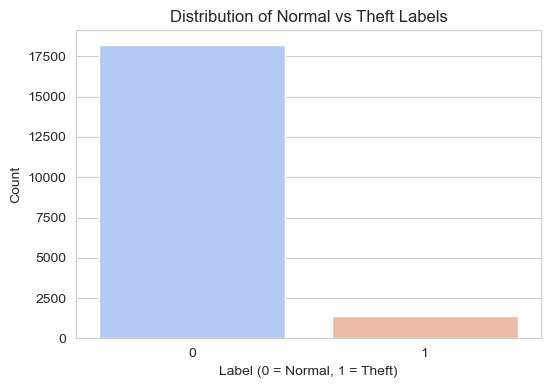

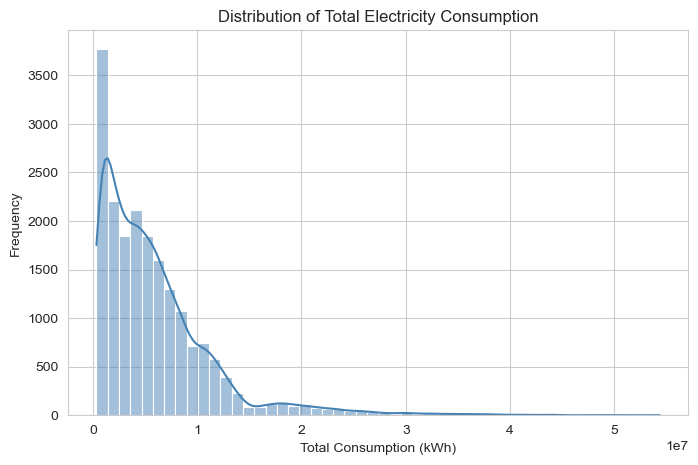

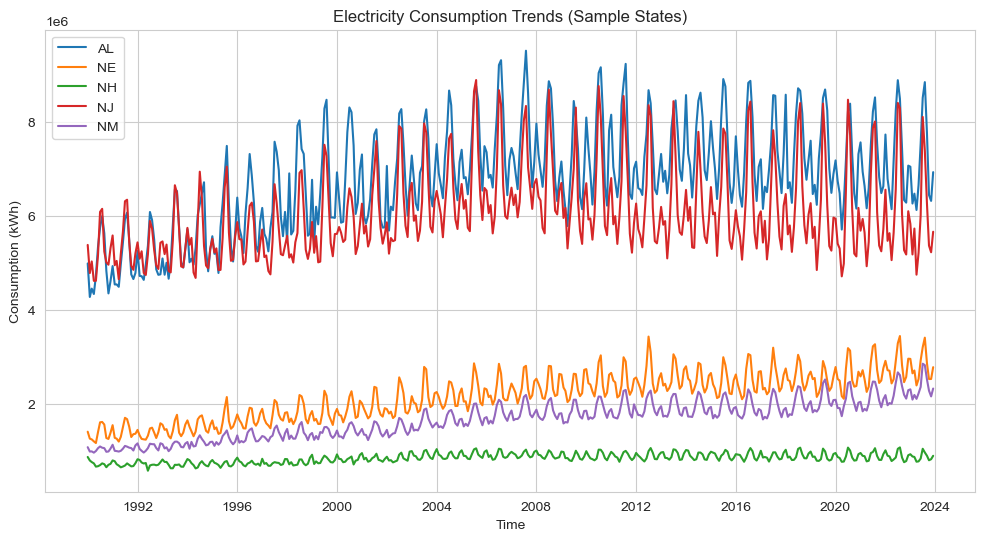

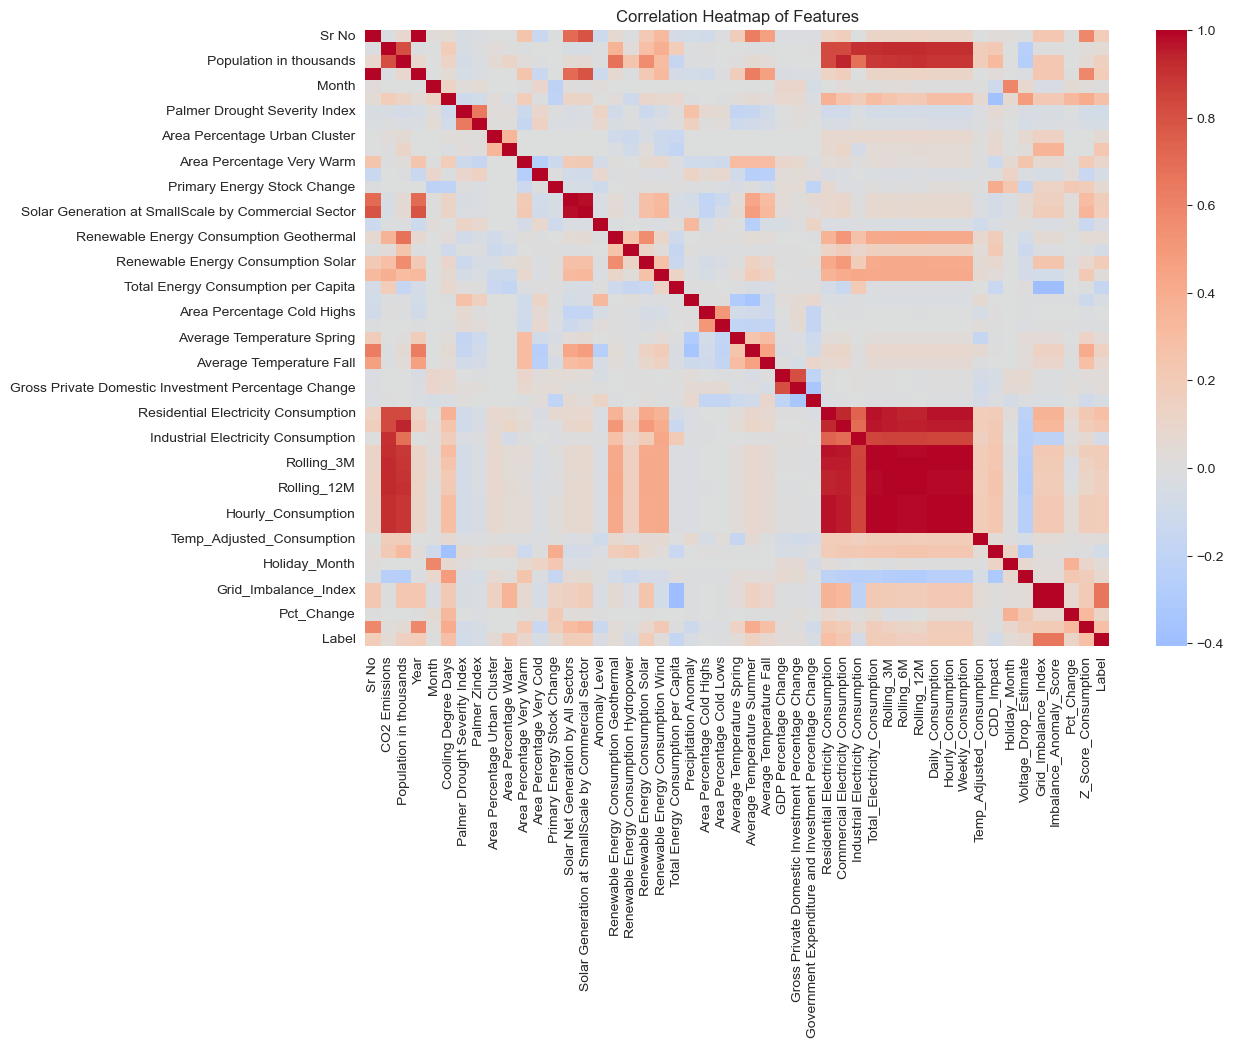

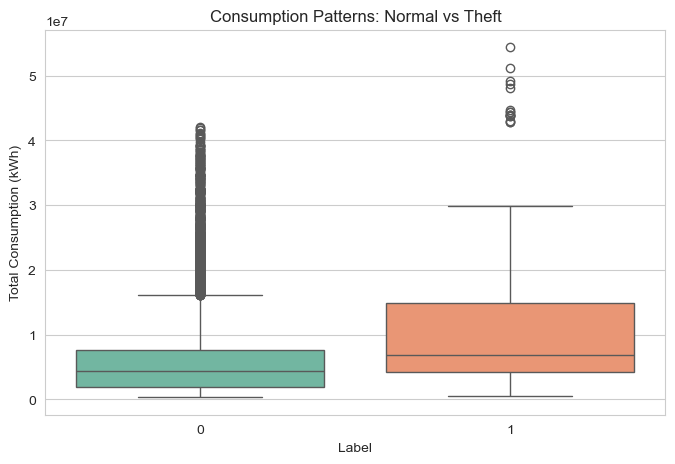

In [11]:
# ============================================================================
# EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================================
print("\n" + "="*80)
print("EXPLORATORY DATA ANALYSIS (EDA)")
print("="*80)

import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Basic Dataset Overview ---
print("\nDataset shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nSummary statistics:\n", df.describe(include='all'))

# --- 2. Label Distribution ---
plt.figure(figsize=(6,4))
sns.countplot(x="Label", data=df, palette="coolwarm")
plt.title("Distribution of Normal vs Theft Labels")
plt.xlabel("Label (0 = Normal, 1 = Theft)")
plt.ylabel("Count")
plt.show()

# --- 3. Consumption Distribution ---
plt.figure(figsize=(8,5))
sns.histplot(df["Total_Electricity_Consumption"], bins=50, kde=True, color="steelblue")
plt.title("Distribution of Total Electricity Consumption")
plt.xlabel("Total Consumption (kWh)")
plt.ylabel("Frequency")
plt.show()

# --- 4. Time-Series Trends ---
plt.figure(figsize=(12,6))
for state in df["State"].unique()[:5]:  # plot first 5 states as sample
    subset = df[df["State"] == state]
    plt.plot(subset["Timestamp"], subset["Total_Electricity_Consumption"], label=state)
plt.title("Electricity Consumption Trends (Sample States)")
plt.xlabel("Time")
plt.ylabel("Consumption (kWh)")
plt.legend()
plt.show()

# --- 5. Correlation Heatmap ---
plt.figure(figsize=(12,8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Heatmap of Features")
plt.show()

# --- 6. Theft vs Normal Comparison ---
plt.figure(figsize=(8,5))
sns.boxplot(x="Label", y="Total_Electricity_Consumption", data=df, palette="Set2")
plt.title("Consumption Patterns: Normal vs Theft")
plt.xlabel("Label")
plt.ylabel("Total Consumption (kWh)")
plt.show()

In [12]:
import networkx as nx

# Initialize directed graph
G = nx.DiGraph()

# --- Add nodes: each State is a node with attributes ---
for _, row in df.iterrows():
    G.add_node(row["State"], 
               year=row["Year"], 
               month=row["Month"],
               residential=row["Residential Electricity Consumption"],
               commercial=row["Commercial Electricity Consumption"],
               industrial=row["Industrial Electricity Consumption"],
               total=row["Total_Electricity_Consumption"],
               z_score=row["Z_Score_Consumption"],
               pct_change=row["Pct_Change"],
               label=row["Label"])

# --- Add edges: synthetic routing or similarity ---
# Example 1: Connect states with same Climate Region
for region in df["Climate Region"].unique():
    states_in_region = df[df["Climate Region"] == region]["State"].unique()
    for i in range(len(states_in_region)-1):
        G.add_edge(states_in_region[i], states_in_region[i+1], type="climate_link")

# Example 2: Connect states with similar GDP trends
for state in df["State"].unique():
    subset = df[df["State"] == state]
    avg_gdp = subset["GDP Percentage Change"].mean()
    for other_state in df["State"].unique():
        if state != other_state:
            other_avg_gdp = df[df["State"] == other_state]["GDP Percentage Change"].mean()
            if abs(avg_gdp - other_avg_gdp) < 2:  # threshold for similarity
                G.add_edge(state, other_state, type="economic_link")


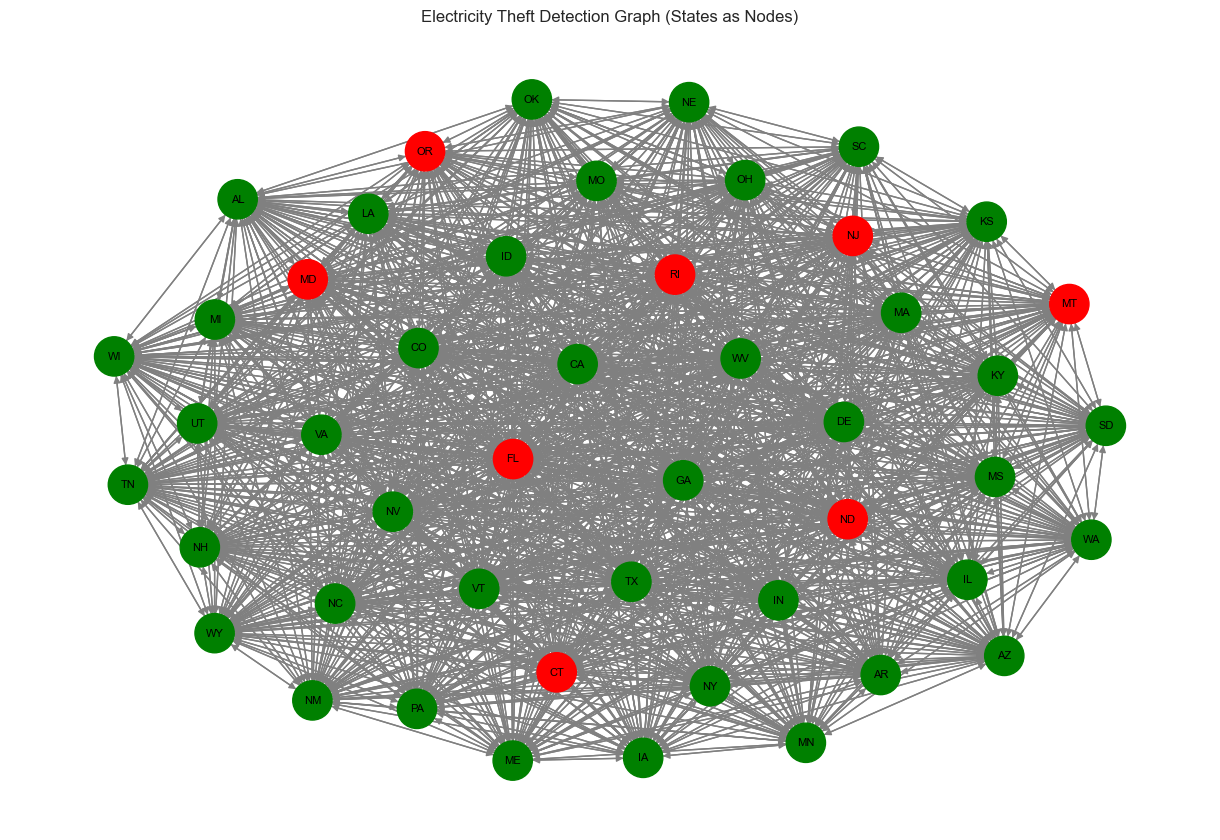

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
pos = nx.spring_layout(G, k=0.3)  # layout for visualization

# Color nodes by theft label
node_colors = ["red" if G.nodes[n]["label"]==1 else "green" for n in G.nodes]

nx.draw(G, pos, with_labels=True, node_color=node_colors, node_size=800, 
        font_size=8, edge_color="gray", arrows=True)

plt.title("Electricity Theft Detection Graph (States as Nodes)")
plt.show()



TIME-SERIES ANOMALY DETECTION (LSTM AUTOENCODER)
States prepared for training: ['AL', 'AR', 'AZ', 'CA', 'CO', 'CT', 'DE', 'GA', 'IA', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA', 'MA', 'MD', 'ME', 'MI', 'MN', 'MO', 'MS', 'MT', 'NC', 'ND', 'NE', 'NH', 'NJ', 'NM', 'NV', 'NY', 'OH', 'OK', 'OR', 'PA', 'RI', 'SC', 'SD', 'TN', 'TX', 'UT', 'VA', 'VT', 'WA', 'WI', 'WV', 'WY']
State AL: threshold=1.047584, normal windows=391, all windows=397
State AR: threshold=0.566143, normal windows=390, all windows=397
State AZ: threshold=0.531481, normal windows=372, all windows=397
State CA: threshold=1.122048, normal windows=382, all windows=397
State CO: threshold=0.585183, normal windows=388, all windows=397
State CT: threshold=1.001999, normal windows=294, all windows=397
State DE: threshold=0.896351, normal windows=385, all windows=397
State GA: threshold=0.705368, normal windows=389, all windows=397
State IA: threshold=0.615772, normal windows=390, all windows=397
State ID: threshold=0.820869, normal window

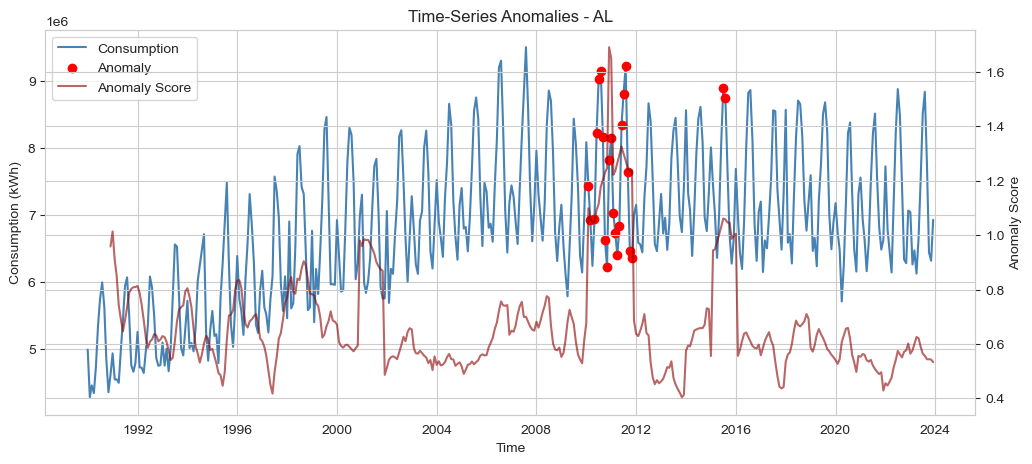

In [14]:
# ============================================================================
# TIME-SERIES ANOMALY DETECTION WITH LSTM AUTOENCODER
# ============================================================================
print("\n" + "="*80)
print("TIME-SERIES ANOMALY DETECTION (LSTM AUTOENCODER)")
print("="*80)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense
from tensorflow.keras.callbacks import EarlyStopping

# -------------------------
# 1) Configuration
# -------------------------
SEQ_LEN = 12           # window length in months
LATENT_DIM = 32        # LSTM units in the bottleneck
BATCH_SIZE = 128
EPOCHS = 50
VAL_SPLIT = 0.1
ANOMALY_PERCENTILE = 95  # threshold based on reconstruction error percentile from normal windows

# -------------------------
# 2) Feature selection
# -------------------------
time_features = [
    "Total_Electricity_Consumption",
    "Rolling_3M", "Rolling_6M", "Rolling_12M",
    "Pct_Change", "Z_Score_Consumption",
    "Holiday_Month", "CDD_Impact", "Voltage_Drop_Estimate"
]

# Ensure required columns exist
missing_cols = [c for c in time_features if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns for time-series model: {missing_cols}")

# Sort by state and time
df = df.sort_values(["State", "Year", "Month"]).reset_index(drop=True)

# -------------------------
# 3) Clean NaNs in features
#    - Impute with median per column
# -------------------------
imputer = SimpleImputer(strategy="median")
df[time_features] = imputer.fit_transform(df[time_features])

# -------------------------
# 4) Build sequences per state
#    - We train on normal windows (Label=0) only
#    - We evaluate anomaly scores on all windows
# -------------------------
def build_sequences(group_df, features, seq_len):
    X = group_df[features].values
    # Create overlapping sequences
    sequences = []
    indices = []
    for i in range(len(X) - seq_len + 1):
        seq = X[i:i+seq_len]
        sequences.append(seq)
        # Index of the last time point in the window
        indices.append(group_df.index[i+seq_len-1])
    return np.array(sequences), np.array(indices)

# Scale per state (robust to distribution differences)
def scale_per_state(group_df, features):
    scaler = StandardScaler()
    group_df[features] = scaler.fit_transform(group_df[features])
    return group_df, scaler

# Collect all state sequences
state_windows = {}  # state -> dict(train_X, all_X, all_idx, scaler)
for state, g in df.groupby("State"):
    g = g.copy()
    # Scale per state
    g, scaler = scale_per_state(g, time_features)
    # Build sequences for all windows and for normal windows
    all_X, all_idx = build_sequences(g, time_features, SEQ_LEN)
    # Label for last row of each window
    labels_last = df.loc[all_idx, "Label"].values
    # Normal windows only for training (Label == 0)
    normal_mask = labels_last == 0
    train_X = all_X[normal_mask]
    # If not enough normal windows, skip state
    if len(train_X) < max(100, SEQ_LEN * 3):
        # Heuristic minimum; adjust as needed
        continue
    state_windows[state] = {
        "train_X": train_X,
        "all_X": all_X,
        "all_idx": all_idx,
        "scaler": scaler
    }

print(f"States prepared for training: {list(state_windows.keys())}")

# -------------------------
# 5) Define LSTM autoencoder
# -------------------------
def build_model(seq_len, n_features, latent_dim=LATENT_DIM):
    inp = Input(shape=(seq_len, n_features))
    x = LSTM(latent_dim, return_sequences=False)(inp)
    x = RepeatVector(seq_len)(x)
    x = LSTM(latent_dim, return_sequences=True)(x)
    out = TimeDistributed(Dense(n_features))(x)
    model = Model(inp, out)
    model.compile(optimizer="adam", loss="mse")
    return model

# -------------------------
# 6) Train per state and score anomalies
# -------------------------
all_scores = np.full(len(df), np.nan)   # reconstruction error per row (last step of each window)
all_flags  = np.zeros(len(df), dtype=int)  # 1 = anomaly

for state, pack in state_windows.items():
    train_X = pack["train_X"]
    all_X   = pack["all_X"]
    all_idx = pack["all_idx"]

    n_features = train_X.shape[-1]
    model = build_model(SEQ_LEN, n_features)

    es = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
    history = model.fit(
        train_X, train_X,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=VAL_SPLIT,
        callbacks=[es],
        verbose=0
    )

    # Reconstruction on normal windows to set threshold
    recon_train = model.predict(train_X, verbose=0)
    train_err = ((train_X - recon_train) ** 2).mean(axis=(1,2))
    threshold = np.percentile(train_err, ANOMALY_PERCENTILE)

    # Score all windows
    recon_all = model.predict(all_X, verbose=0)
    all_err = ((all_X - recon_all) ** 2).mean(axis=(1,2))

    # Map window error to the last index of each window
    all_scores[all_idx] = all_err
    all_flags[all_idx] = (all_err > threshold).astype(int)

    print(f"State {state}: threshold={threshold:.6f}, normal windows={len(train_X)}, all windows={len(all_X)}")

# -------------------------
# 7) Attach anomaly scores and flags to df
# -------------------------
df["TS_Anomaly_Score"] = all_scores
df["TS_Anomaly_Flag"]  = all_flags

print("\nAnomaly scoring complete.")
print(df[["State","Year","Month","Total_Electricity_Consumption","TS_Anomaly_Score","TS_Anomaly_Flag","Label"]].head(20))

# -------------------------
# 8) Evaluate alignment with synthetic labels
# -------------------------
valid_mask = ~df["TS_Anomaly_Score"].isna()
if valid_mask.sum() > 0:
    from sklearn.metrics import classification_report
    # Compare TS_Anomaly_Flag vs existing Label (rule-based) where scores exist
    print("\nClassification report (TS_Anomaly_Flag vs Label):")
    print(classification_report(df.loc[valid_mask, "Label"], df.loc[valid_mask, "TS_Anomaly_Flag"], digits=3))
else:
    print("\nNo valid anomaly scores computed (check minimum windows per state).")

# -------------------------
# 9) Visualization for a sample state
# -------------------------
sample_state = next(iter(state_windows.keys())) if state_windows else None
if sample_state:
    g = df[df["State"] == sample_state].copy()
    fig, ax1 = plt.subplots(figsize=(12,5))
    ax1.plot(g["Timestamp"], g["Total_Electricity_Consumption"], color="steelblue", label="Consumption")
    ax1.set_ylabel("Consumption (kWh)")
    ax1.set_xlabel("Time")
    ax2 = ax1.twinx()
    ax2.plot(g["Timestamp"], g["TS_Anomaly_Score"], color="darkred", alpha=0.6, label="Anomaly Score")
    ax2.set_ylabel("Anomaly Score")
    # Highlight anomalies
    anomalies = g[g["TS_Anomaly_Flag"] == 1]
    ax1.scatter(anomalies["Timestamp"], anomalies["Total_Electricity_Consumption"],
                color="red", label="Anomaly", zorder=3)
    plt.title(f"Time-Series Anomalies - {sample_state}")
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines + lines2, labels + labels2, loc="upper left")
    plt.show()
else:
    print("\nNo state had enough normal windows to train. Consider reducing SEQ_LEN or minimum window count.")



SUPERVISED THEFT CLASSIFICATION MODEL (NO LEAKAGE)

Random Forest Classification Report:
              precision    recall  f1-score   support

           0      0.981     0.999     0.990      3642
           1      0.981     0.749     0.849       275

    accuracy                          0.981      3917
   macro avg      0.981     0.874     0.920      3917
weighted avg      0.981     0.981     0.980      3917

Random Forest ROC-AUC Score: 0.997

Gradient Boosting Classification Report:
              precision    recall  f1-score   support

           0      0.977     0.998     0.987      3642
           1      0.959     0.687     0.801       275

    accuracy                          0.976      3917
   macro avg      0.968     0.843     0.894      3917
weighted avg      0.976     0.976     0.974      3917

Gradient Boosting ROC-AUC Score: 0.983

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0      0.986     0.900     0.9

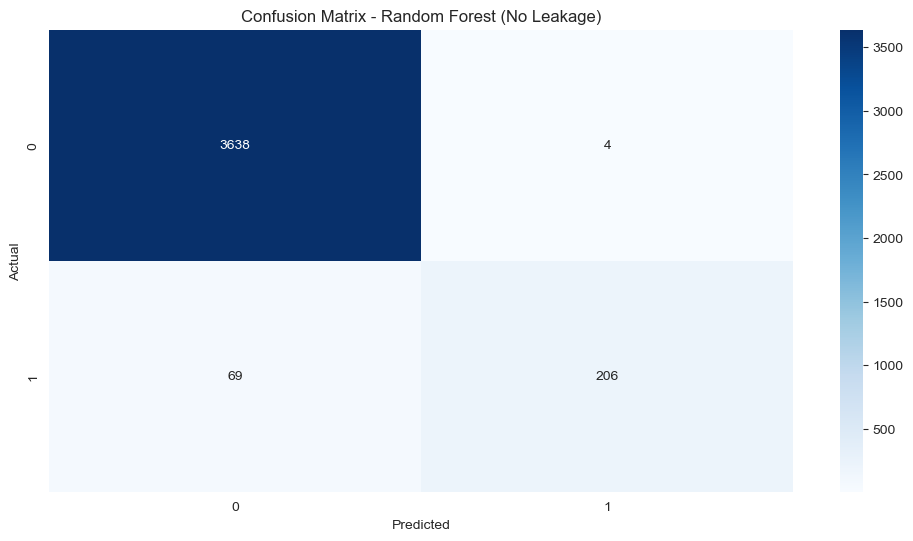

In [16]:
# ============================================================================
# SUPERVISED THEFT CLASSIFICATION MODEL (NO LEAKAGE)
# ============================================================================
print("\n" + "="*80)
print("SUPERVISED THEFT CLASSIFICATION MODEL (NO LEAKAGE)")
print("="*80)

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------
# 1) Prepare dataset
# -------------------------
safe_features = [
    # Core consumption
    "Total_Electricity_Consumption",
    "Residential Electricity Consumption",
    "Commercial Electricity Consumption",
    "Industrial Electricity Consumption",
    
    # Rolling averages
    "Rolling_3M", "Rolling_6M", "Rolling_12M",
    
    # Derived consumption proxies
    "Daily_Consumption", "Hourly_Consumption", "Weekly_Consumption",
    
    # Climate/weather influence
    "Cooling Degree Days", "Average Temperature Spring",
    "Average Temperature Summer", "Average Temperature Fall",
    "Holiday_Month", "CDD_Impact",
    
    # Grid imbalance proxies
    "Voltage_Drop_Estimate", "Grid_Imbalance_Index",
    
    # Change/anomaly signals (but not direct flags)
    "Pct_Change"
]

df_model = df[safe_features + ["Label"]].dropna()

X = df_model[safe_features]
y = df_model["Label"]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

# -------------------------
# 2) Train models
# -------------------------
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "SVM": SVC(probability=True, class_weight="balanced")
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1] if hasattr(model, "predict_proba") else None
    
    print(f"\n{name} Classification Report:")
    print(classification_report(y_test, y_pred, digits=3))
    
    if y_prob is not None:
        auc = roc_auc_score(y_test, y_prob)
        print(f"{name} ROC-AUC Score: {auc:.3f}")
        results[name] = {"model": model, "roc_auc": auc}

# -------------------------
# 3) Confusion Matrix for Best Model
# -------------------------
best_model_name = max(results, key=lambda k: results[k]["roc_auc"])
best_model = results[best_model_name]["model"]
y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name} (No Leakage)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [17]:
importances = best_model.feature_importances_
feature_importance = pd.DataFrame({
    "Feature": safe_features,
    "Importance": importances
}).sort_values("Importance", ascending=False)
print(feature_importance)


                                Feature  Importance
17                 Grid_Imbalance_Index    0.423098
3    Industrial Electricity Consumption    0.094617
1   Residential Electricity Consumption    0.050593
0         Total_Electricity_Consumption    0.043496
2    Commercial Electricity Consumption    0.041867
6                           Rolling_12M    0.038718
8                    Hourly_Consumption    0.037579
9                    Weekly_Consumption    0.037152
15                           CDD_Impact    0.036269
7                     Daily_Consumption    0.035279
10                  Cooling Degree Days    0.033281
16                Voltage_Drop_Estimate    0.025394
5                            Rolling_6M    0.023001
12           Average Temperature Summer    0.021154
4                            Rolling_3M    0.020781
18                           Pct_Change    0.020376
13             Average Temperature Fall    0.008016
11           Average Temperature Spring    0.006039
14          


MODEL COMPARISON

Model performance comparison:
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
      Random Forest  0.981363   0.980952 0.749091  0.849485 0.997115
  Gradient Boosting  0.976002   0.959391 0.687273  0.800847 0.982726
Logistic Regression  0.895839   0.387858 0.836364  0.529954 0.939656
                SVM  0.932346   0.510593 0.876364  0.645248 0.975965

Best model: Random Forest (F1=0.8495)

Generating comparison plots...


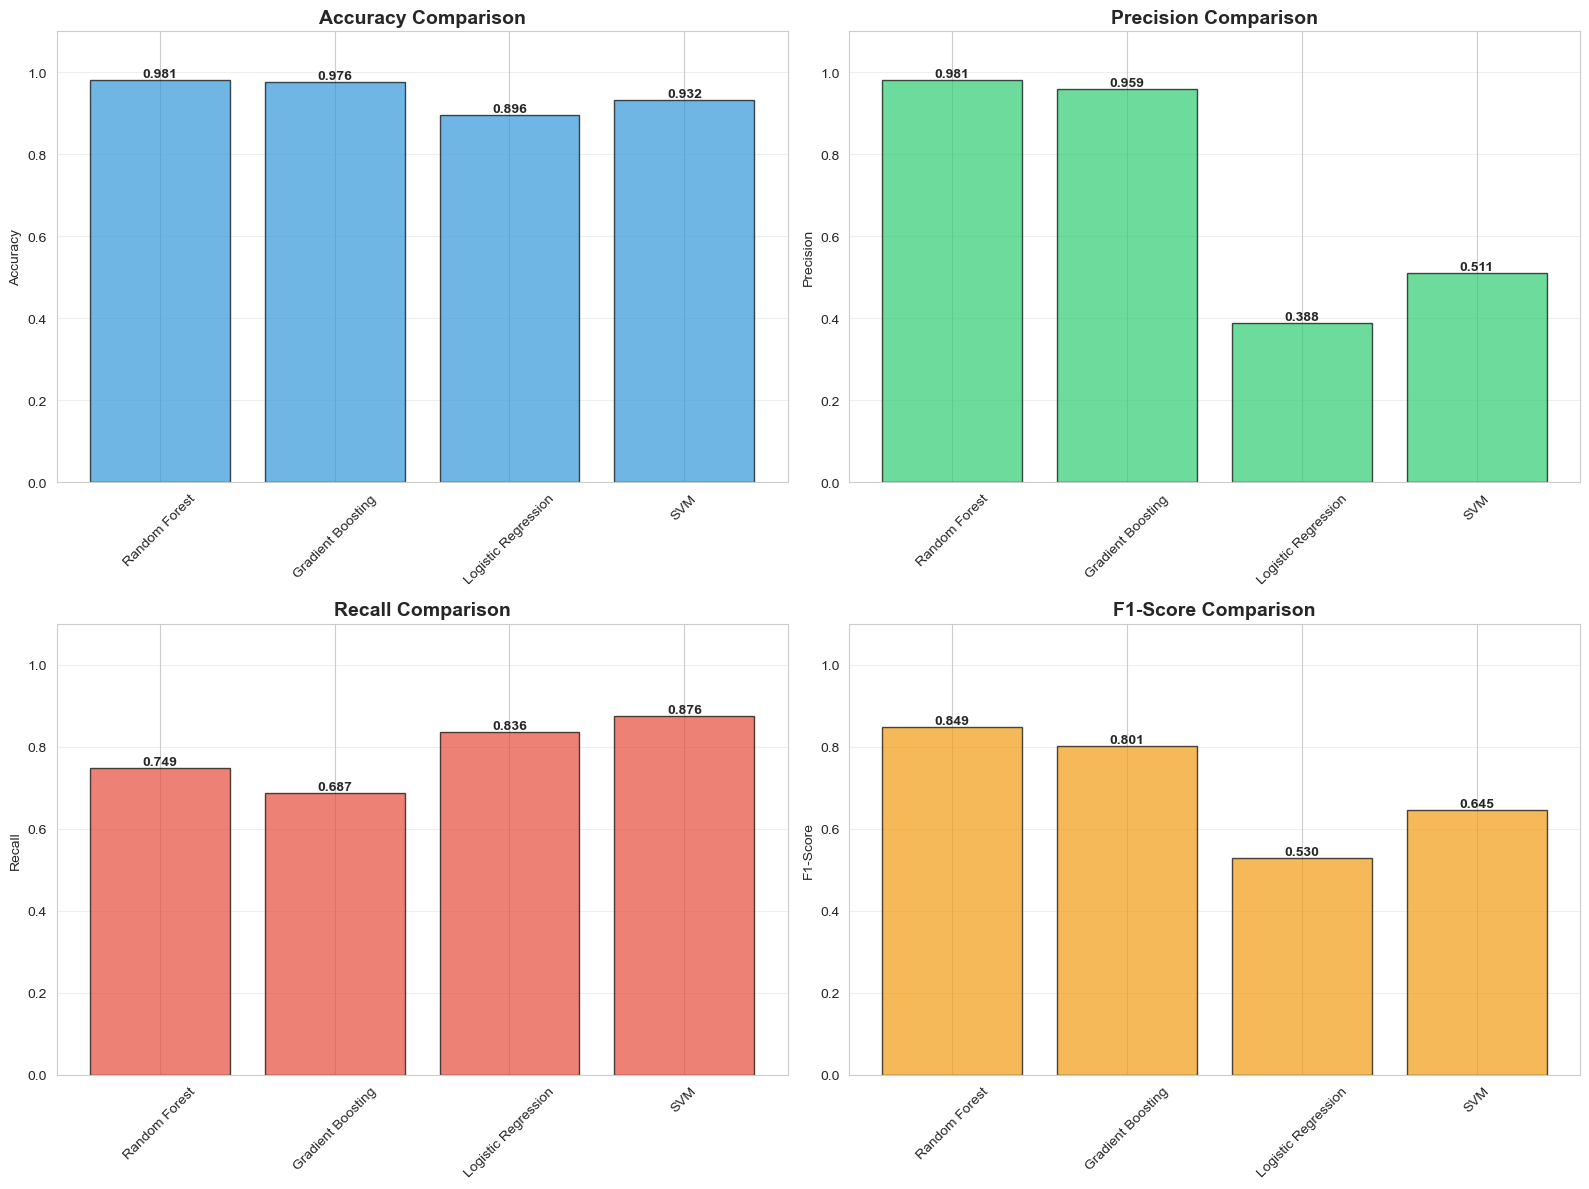

In [18]:
# ============================================================================
# MODEL COMPARISON
# ============================================================================
print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

comparison_data = []

for name, pack in results.items():
    model = pack["model"]
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    comparison_data.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "ROC-AUC": pack.get("roc_auc", None)
    })

comparison_df = pd.DataFrame(comparison_data)

print("\nModel performance comparison:")
print(comparison_df.to_string(index=False))

best_model_name = comparison_df.loc[comparison_df['F1-Score'].idxmax(), 'Model']
print(f"\nBest model: {best_model_name} (F1={comparison_df['F1-Score'].max():.4f})")

# -------------------------
# Visualization
# -------------------------
print("\nGenerating comparison plots...")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    bars = ax.bar(comparison_df['Model'], comparison_df[metric], 
                  color=colors[idx], alpha=0.7, edgecolor='black')
    ax.set_title(f'{metric} Comparison', fontsize=14, fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_ylim([0, 1.1])
    ax.grid(axis='y', alpha=0.3)
    
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontweight='bold')
    
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


CONFUSION MATRICES

Generating confusion matrices...


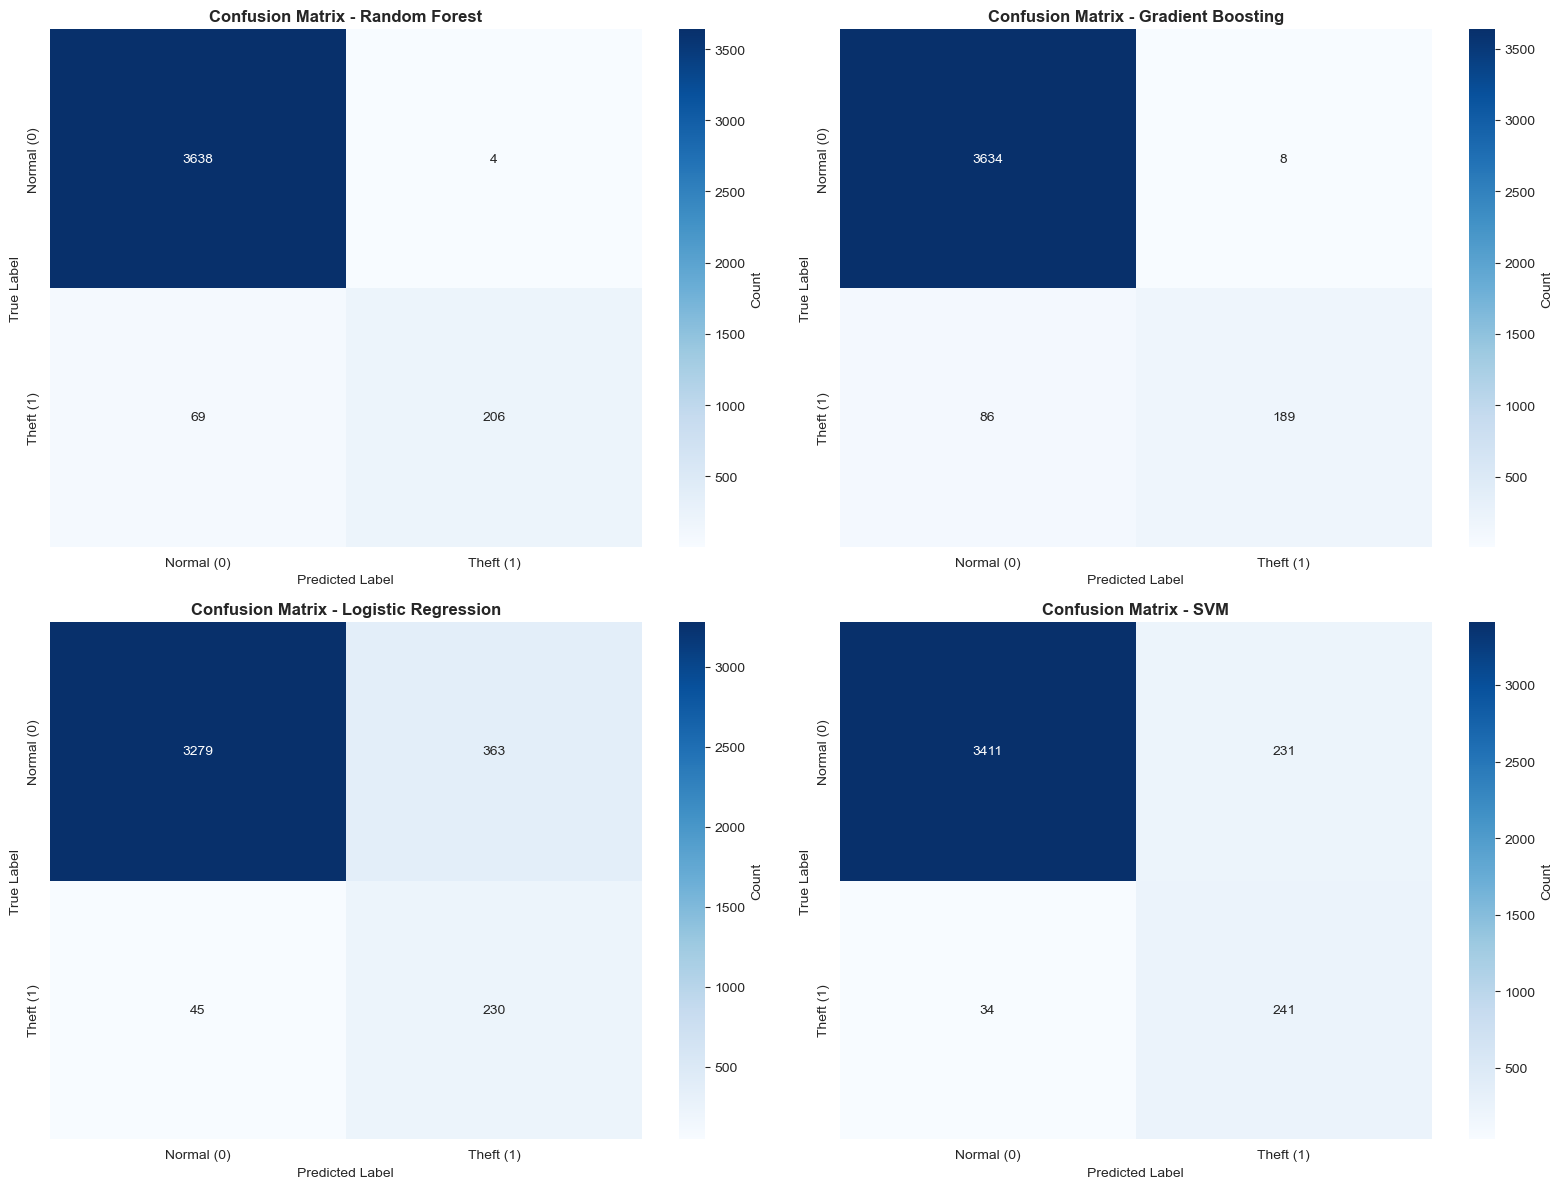

In [19]:
# ============================================================================
# CONFUSION MATRICES
# ============================================================================
print("\n" + "="*80)
print("CONFUSION MATRICES")
print("="*80)

print("\nGenerating confusion matrices...")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

# Define label names manually (0 = Normal, 1 = Theft)
label_names = ["Normal (0)", "Theft (1)"]

for idx, (model_name, pack) in enumerate(results.items()):
    model = pack["model"]
    y_pred = model.predict(X_test)
    
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=label_names,
                yticklabels=label_names,
                cbar_kws={'label': 'Count'})
    axes[idx].set_title(f'Confusion Matrix - {model_name}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()


ROC CURVES

Generating ROC curves...


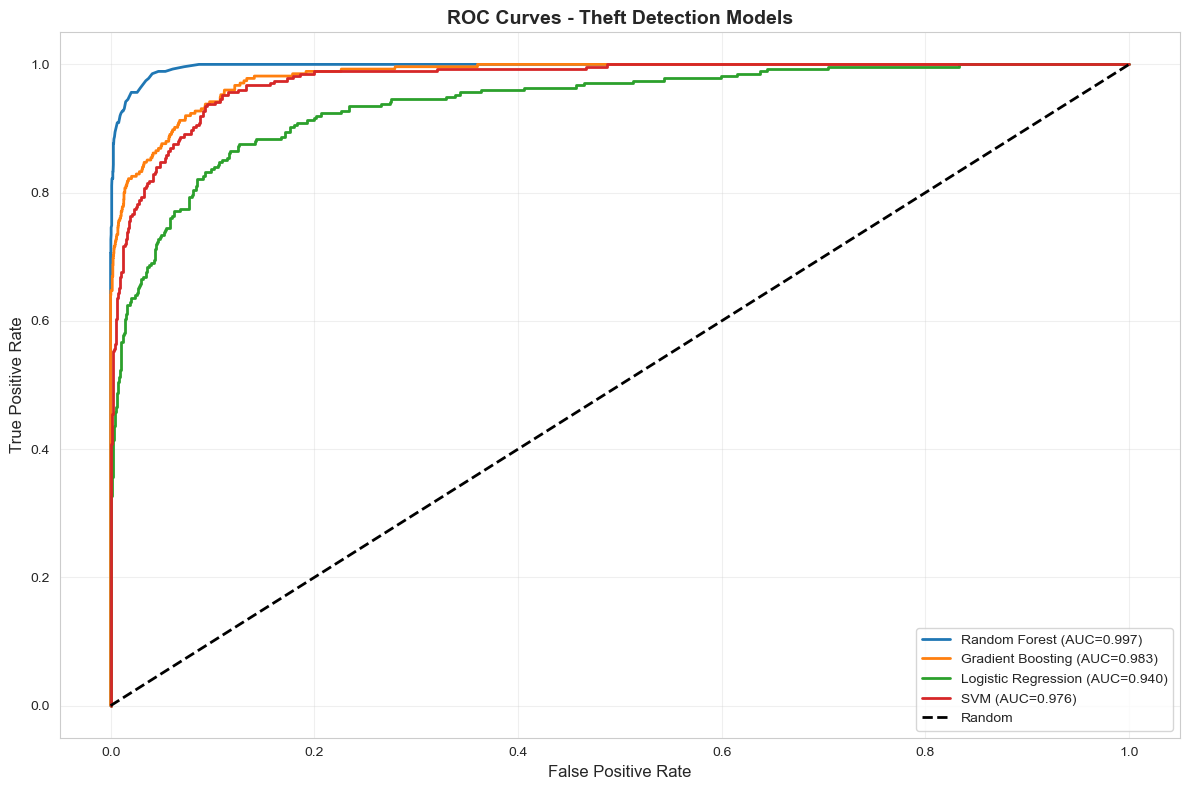

In [20]:
# ============================================================================
# ROC CURVES
# ============================================================================
print("\n" + "="*80)
print("ROC CURVES")
print("="*80)

from sklearn.metrics import roc_curve, roc_auc_score

print("\nGenerating ROC curves...")
plt.figure(figsize=(12, 8))

for model_name, pack in results.items():
    model = pack["model"]
    
    # Only models with probability outputs can be used
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]  # probability of theft (class 1)
        
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc_score = roc_auc_score(y_test, y_prob)
        
        plt.plot(fpr, tpr, label=f'{model_name} (AUC={auc_score:.3f})', linewidth=2)

# Random baseline
plt.plot([0, 1], [0, 1], 'k--', label='Random', linewidth=2)

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Theft Detection Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [21]:
# ============================================================================
# GRAPH NEURAL NETWORK FOR ELECTRICITY THEFT DETECTION
# ============================================================================
print("\n" + "="*80)
print("GRAPH NEURAL NETWORK (GNN) MODEL")
print("="*80)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, GATConv

# -------------------------
# 1) Build Graph Data
# -------------------------
# Example: nodes = states/meters, edges = similarity or routing
# X = node features (consumption, imbalance, anomalies)
# y = labels (0 = normal, 1 = theft)

# Convert your dataframe into tensors
X = torch.tensor(df[safe_features].values, dtype=torch.float)
y = torch.tensor(df["Label"].values, dtype=torch.long)

# Example edge index (replace with your transformer-feeder-meter mapping)
# Shape: [2, num_edges]
edge_index = torch.tensor([
    [0, 1, 2, 3],   # source nodes
    [1, 2, 3, 4]    # target nodes
], dtype=torch.long)

data = Data(x=X, edge_index=edge_index, y=y)

# -------------------------
# 2) Define GNN Model
# -------------------------
class TheftGCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(TheftGCN, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.fc = nn.Linear(hidden_channels, out_channels)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = self.fc(x)
        return F.log_softmax(x, dim=1)

model = TheftGCN(in_channels=X.shape[1], hidden_channels=64, out_channels=2)

# -------------------------
# 3) Training Loop
# -------------------------
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

for epoch in range(50):
    model.train()
    optimizer.zero_grad()
    out = model(data)
    loss = F.nll_loss(out, data.y)
    loss.backward()
    optimizer.step()
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

# -------------------------
# 4) Predictions
# -------------------------
model.eval()
pred = model(data).argmax(dim=1)
print("\nSample predictions:", pred[:20])


GRAPH NEURAL NETWORK (GNN) MODEL
Epoch 1, Loss: 381547.2500
Epoch 2, Loss: 281698.9688
Epoch 3, Loss: 401437.2812
Epoch 4, Loss: 431173.5938
Epoch 5, Loss: 403712.2812
Epoch 6, Loss: 343948.0625
Epoch 7, Loss: 261324.1094
Epoch 8, Loss: 167995.6250
Epoch 9, Loss: 65854.2812
Epoch 10, Loss: 219462.2031
Epoch 11, Loss: 8122.1104
Epoch 12, Loss: 32948.9219
Epoch 13, Loss: 49540.8086
Epoch 14, Loss: 56269.0586
Epoch 15, Loss: 53952.2773
Epoch 16, Loss: 43019.1016
Epoch 17, Loss: 23867.9141
Epoch 18, Loss: 15321.5586
Epoch 19, Loss: 6313.4673
Epoch 20, Loss: 9939.5127
Epoch 21, Loss: 9738.6680
Epoch 22, Loss: 5039.7676
Epoch 23, Loss: 14058.7676
Epoch 24, Loss: 6448.9185
Epoch 25, Loss: 10135.6094
Epoch 26, Loss: 8001.0664
Epoch 27, Loss: 4219.5996
Epoch 28, Loss: 6493.8496
Epoch 29, Loss: 3483.1982
Epoch 30, Loss: 4800.1382
Epoch 31, Loss: 3872.6519
Epoch 32, Loss: 2969.5332
Epoch 33, Loss: 4080.1826
Epoch 34, Loss: 2530.2156
Epoch 35, Loss: 3396.0657
Epoch 36, Loss: 2502.3733
Epoch 37, L


GRAPH NEURAL NETWORK (GNN) PIPELINE
Epoch 5, Loss: 260595.6250
Epoch 10, Loss: 124043.1562
Epoch 15, Loss: 40414.9414
Epoch 20, Loss: 15208.8633
Epoch 25, Loss: 7106.0610
Epoch 30, Loss: 4850.1445
Epoch 35, Loss: 3592.9038
Epoch 40, Loss: 2506.3777
Epoch 45, Loss: 1666.2668
Epoch 50, Loss: 934.9258

Classification Report (GNN):
              precision    recall  f1-score   support

           0      0.976     0.899     0.936     18210
           1      0.347     0.712     0.466      1374

    accuracy                          0.886     19584
   macro avg      0.662     0.805     0.701     19584
weighted avg      0.932     0.886     0.903     19584



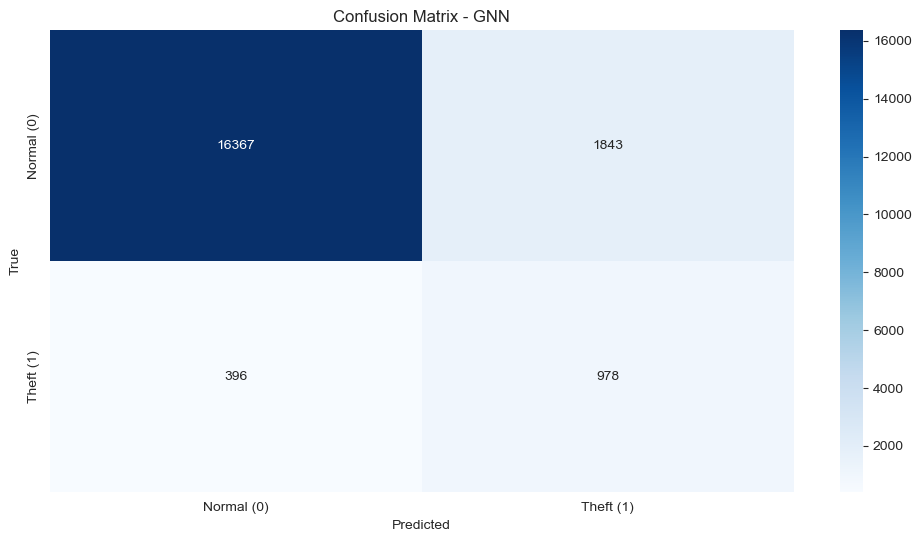

In [22]:
# ============================================================================
# GRAPH NEURAL NETWORK (GNN) PIPELINE FOR ELECTRICITY THEFT DETECTION
# ============================================================================
print("\n" + "="*80)
print("GRAPH NEURAL NETWORK (GNN) PIPELINE")
print("="*80)

import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------
# 1) Prepare Node Features
# -------------------------
gnn_features = [
    "Total_Electricity_Consumption",
    "Residential Electricity Consumption",
    "Commercial Electricity Consumption",
    "Industrial Electricity Consumption",
    "Rolling_3M", "Rolling_6M", "Rolling_12M",
    "Daily_Consumption", "Hourly_Consumption", "Weekly_Consumption",
    "Cooling Degree Days", "Average Temperature Spring",
    "Average Temperature Summer", "Average Temperature Fall",
    "Holiday_Month", "CDD_Impact",
    "Voltage_Drop_Estimate", "Grid_Imbalance_Index", "Imbalance_Anomaly_Score",
    "Pct_Change", "Z_Score_Consumption"
]

X = torch.tensor(df[gnn_features].values, dtype=torch.float)
y = torch.tensor(df["Label"].values, dtype=torch.long)

# -------------------------
# 2) Build Graph Structure
# -------------------------
# Replace this with your real transformer → feeder → meter edges
# For now, we simulate edges by connecting consecutive nodes
num_nodes = X.shape[0]
edge_index = torch.tensor([
    list(range(num_nodes-1)),
    list(range(1, num_nodes))
], dtype=torch.long)

# -------------------------
# 3) Define GNN Model
# -------------------------
class TheftGCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(TheftGCN, self).__init__()
        self.fc1 = nn.Linear(in_channels, hidden_channels)
        self.fc2 = nn.Linear(hidden_channels, hidden_channels)
        self.fc_out = nn.Linear(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        # Simple neighborhood aggregation (mean of neighbors)
        # For real PyG, replace with GCNConv/GATConv
        row, col = edge_index
        agg = torch.zeros_like(x)
        agg.index_add_(0, row, x[col])
        x = x + agg / (torch.bincount(row, minlength=x.size(0)).unsqueeze(1) + 1e-6)

        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc_out(x)
        return F.log_softmax(x, dim=1)

model = TheftGCN(in_channels=X.shape[1], hidden_channels=64, out_channels=2)

# -------------------------
# 4) Training Loop with Class Weights
# -------------------------
class_counts = torch.bincount(y)
weights = 1.0 / (class_counts.float() + 1e-6)  # inverse frequency
weights = weights / weights.sum() * 2          # normalize to sum=2

optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

for epoch in range(50):
    model.train()
    optimizer.zero_grad()
    out = model(X, edge_index)
    loss = F.nll_loss(out, y, weight=weights)
    loss.backward()
    optimizer.step()
    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

# -------------------------
# 5) Evaluation
# -------------------------
model.eval()
pred = model(X, edge_index).argmax(dim=1)

print("\nClassification Report (GNN):")
print(classification_report(y.numpy(), pred.numpy(), digits=3))

cm = confusion_matrix(y.numpy(), pred.numpy())
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal (0)", "Theft (1)"],
            yticklabels=["Normal (0)", "Theft (1)"])
plt.title("Confusion Matrix - GNN")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()



INTEGRATED GNN + HYBRID THEFT SCORING PIPELINE (CLEANED & ROBUST)
Using supervised best model: Random Forest
Epoch 5, Loss: 0.5729
Epoch 10, Loss: 0.5308
Epoch 15, Loss: 0.5078
Epoch 20, Loss: 0.4902
Epoch 25, Loss: 0.4689
Epoch 30, Loss: 0.4358
Epoch 35, Loss: 0.4136
Epoch 40, Loss: 0.3968
Epoch 45, Loss: 0.3770
Epoch 50, Loss: 0.3583
Epoch 55, Loss: 0.3483
Epoch 60, Loss: 0.3215

GNN PR-AUC (theft): 0.632, Best threshold by PR-F1: 0.777

Classification Report (GNN, calibrated threshold):
              precision    recall  f1-score   support

           0      0.973     0.952     0.962     18210
           1      0.505     0.648     0.568      1374

    accuracy                          0.931     19584
   macro avg      0.739     0.800     0.765     19584
weighted avg      0.940     0.931     0.935     19584



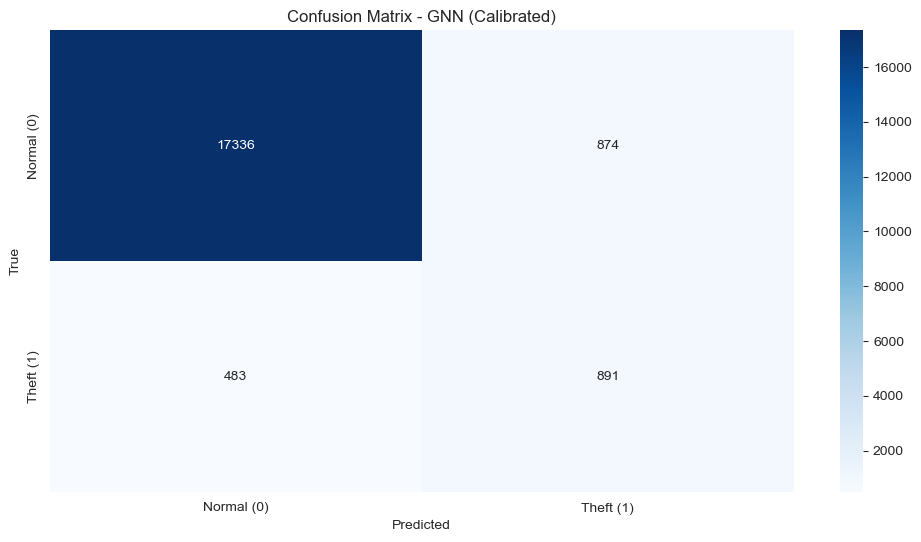


ALIGNING df_gnn WITH SUPERVISED TRAINING FEATURES (AUTO-FIX)

Scaler expects 19 supervised features:
['Total_Electricity_Consumption', 'Residential Electricity Consumption', 'Commercial Electricity Consumption', 'Industrial Electricity Consumption', 'Rolling_3M', 'Rolling_6M', 'Rolling_12M', 'Daily_Consumption', 'Hourly_Consumption', 'Weekly_Consumption', 'Cooling Degree Days', 'Average Temperature Spring', 'Average Temperature Summer', 'Average Temperature Fall', 'Holiday_Month', 'CDD_Impact', 'Voltage_Drop_Estimate', 'Grid_Imbalance_Index', 'Pct_Change']

Hybrid PR-AUC (theft): 0.533, Best hybrid threshold: 0.537

Classification Report (Hybrid):
              precision    recall  f1-score   support

           0      0.963     0.970     0.966     18210
           1      0.554     0.500     0.525      1374

    accuracy                          0.937     19584
   macro avg      0.758     0.735     0.746     19584
weighted avg      0.934     0.937     0.935     19584



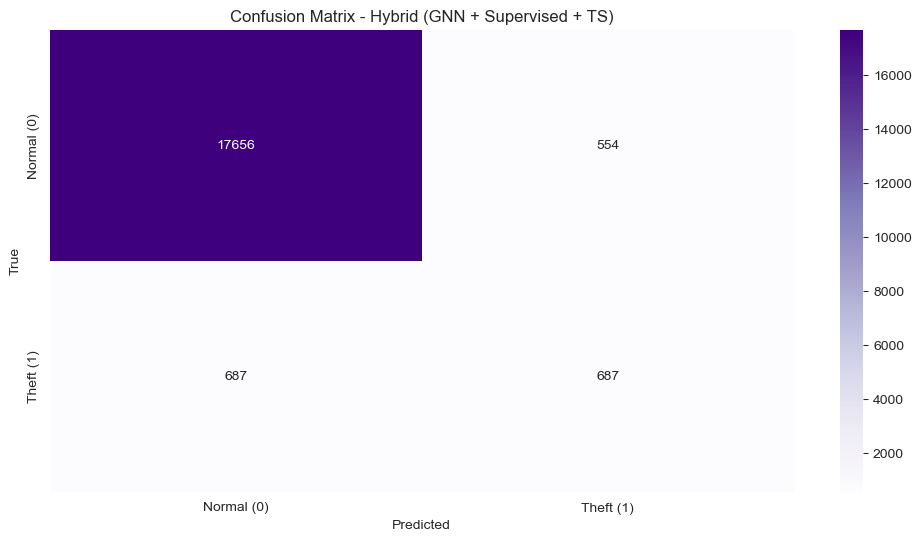


Sample of hybrid outputs:
State  GNN_Prob_Theft  Supervised_Prob_Theft  TS_Anomaly_Score_Scaled  Hybrid_Theft_Score  Hybrid_Theft_Flag
   AL    7.596640e-15                   0.13                      0.0               0.052                0.0
   AL    7.200230e-16                   0.13                      0.0               0.052                0.0
   AL    9.720065e-16                   0.24                      0.0               0.096                0.0
   AL    1.778521e-16                   0.13                      0.0               0.052                0.0
   AL    3.766607e-17                   0.27                      0.0               0.108                0.0
   AL    7.145553e-18                   0.27                      0.0               0.108                0.0
   AL    4.337586e-18                   0.26                      0.0               0.104                0.0
   AL    7.596083e-17                   0.27                      0.0               0.108            

In [42]:
# ============================================================================
# INTEGRATED GNN + HYBRID THEFT SCORING PIPELINE (CLEANED & ROBUST)
# ============================================================================
print("\n" + "="*80)
print("INTEGRATED GNN + HYBRID THEFT SCORING PIPELINE (CLEANED & ROBUST)")
print("="*80)

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import (
    classification_report, confusion_matrix, precision_recall_curve,
    average_precision_score
)
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------
# 0) Inputs expected from prior steps
#    - df with engineered features and Label
#    - results dict from supervised models (contains best model with predict_proba and 'roc_auc')
#    - scaler: the EXACT StandardScaler fitted during supervised training
#    - df includes TS_Anomaly_Score (from LSTM autoencoder) optionally
# -------------------------
if 'results' not in globals() or not results:
    raise ValueError("No supervised results found. Train supervised models first and populate `results` dict.")
if 'scaler' not in globals():
    raise ValueError("scaler not found. Provide the fitted scaler from supervised training (StandardScaler).")

best_sup_name = max(results, key=lambda k: results[k].get("roc_auc", 0))
best_sup_model = results[best_sup_name]["model"]
print(f"Using supervised best model: {best_sup_name}")

# -------------------------
# 1) Feature normalization per group (for GNN only)
# -------------------------
group_key = "State" if "State" in df.columns else None

# GNN features (include possible optional features - presence handled later)
gnn_features = [
    "Total_Electricity_Consumption",
    "Residential Electricity Consumption",
    "Commercial Electricity Consumption",
    "Industrial Electricity Consumption",
    "Rolling_3M", "Rolling_6M", "Rolling_12M",
    "Daily_Consumption", "Hourly_Consumption", "Weekly_Consumption",
    "Cooling Degree Days", "Average Temperature Spring",
    "Average Temperature Summer", "Average Temperature Fall",
    "Holiday_Month", "CDD_Impact",
    "Voltage_Drop_Estimate", "Grid_Imbalance_Index", "Imbalance_Anomaly_Score",
    "Pct_Change", "Z_Score_Consumption", "Temp_Adjusted_Consumption", "TS_Anomaly_Score"
]

# required columns for labeling
required_cols = ["Label"]
if group_key:
    required_cols.append(group_key)

# Build df_gnn carefully: keep all gnn_features (if missing, add NaN then fill later)
df_gnn = df.copy()  # start from df so we retain all columns and indices
# Ensure all gnn_features exist (create if missing)
for col in gnn_features:
    if col not in df_gnn.columns:
        df_gnn[col] = np.nan

# Keep only rows with non-null Label (can't train without label)
if "Label" not in df_gnn.columns:
    raise ValueError("Label column not found in df. Supervised training requires a 'Label' column (0/1).")
df_gnn = df_gnn[df_gnn["Label"].notna()].copy()

# Fill TS_Anomaly_Score or other optional features with zeros if missing
optional_to_fill_zero = ["TS_Anomaly_Score", "Temp_Adjusted_Consumption", "Imbalance_Anomaly_Score", "Z_Score_Consumption"]
for c in optional_to_fill_zero:
    if c in df_gnn.columns:
        df_gnn[c] = pd.to_numeric(df_gnn[c], errors="coerce").fillna(0)
    else:
        df_gnn[c] = 0

# Convert numeric-looking columns to numeric (safe)
for c in gnn_features:
    df_gnn[c] = pd.to_numeric(df_gnn[c], errors="coerce")

# Now, do groupwise normalization but safely:
def normalize_groupwise_safe(data, feat_cols, key):
    from sklearn.preprocessing import StandardScaler
    if key is None:
        # global scaling
        scaler_local = StandardScaler()
        data[feat_cols] = scaler_local.fit_transform(data[feat_cols].fillna(0))
        return data
    out_chunks = []
    for k, g in data.groupby(key):
        if len(g) < 2:
            # can't fit scaler on single row: just fillna(0) and leave as-is
            g[feat_cols] = g[feat_cols].fillna(0)
        else:
            scaler_local = StandardScaler()
            g_idx = g.index
            # fill NA with group median before scaling
            g[feat_cols] = g[feat_cols].fillna(g[feat_cols].median())
            g.loc[g_idx, feat_cols] = scaler_local.fit_transform(g[feat_cols])
        out_chunks.append(g)
    return pd.concat(out_chunks, axis=0).sort_index()

df_gnn = normalize_groupwise_safe(df_gnn, gnn_features, group_key)

# -------------------------
# 2) Build simple graph structure (replace with real topology if available)
# -------------------------
indices = df_gnn.index.to_numpy()

edges_src, edges_dst = [], []
if group_key:
    for k, g in df_gnn.groupby(group_key):
        idxs = g.index.to_list()
        if len(idxs) > 1:
            edges_src.extend(idxs[:-1])
            edges_dst.extend(idxs[1:])
else:
    idxs = df_gnn.index.to_list()
    if len(idxs) > 1:
        edges_src.extend(idxs[:-1])
        edges_dst.extend(idxs[1:])

if len(edges_src) == 0:
    raise RuntimeError("Unable to build graph edges: not enough rows per group or no groups found. Provide topology or more rows.")

id_map = {idx: i for i, idx in enumerate(indices)}
edge_index = torch.tensor([
    [id_map[s] for s in edges_src],
    [id_map[t] for t in edges_dst]
], dtype=torch.long)

# Ensure X and y match df_gnn order
X = torch.tensor(df_gnn[gnn_features].values, dtype=torch.float)
y = torch.tensor(df_gnn["Label"].astype(int).values, dtype=torch.long)

# -------------------------
# 3) Define lightweight GNN (pure PyTorch)
# -------------------------
class TheftGCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.2):
        super().__init__()
        self.fc1 = nn.Linear(in_channels, hidden_channels)
        self.fc2 = nn.Linear(hidden_channels, hidden_channels)
        self.out = nn.Linear(hidden_channels, out_channels)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, edge_index):
        row, col = edge_index
        agg = torch.zeros_like(x)
        agg.index_add_(0, row, x[col])
        deg = torch.bincount(row, minlength=x.size(0)).float().unsqueeze(1)
        x = x + agg / (deg + 1e-6)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.relu(self.fc2(x))
        x = self.dropout(x)
        logits = self.out(x)
        return torch.log_softmax(logits, dim=1), torch.softmax(logits, dim=1)

model = TheftGCN(in_channels=X.shape[1], hidden_channels=128, out_channels=2, dropout=0.2)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

# -------------------------
# 4) Stronger class weights for imbalance
# -------------------------
# compute safe class weights from data if desired
counts = np.bincount(y.numpy())
if len(counts) < 2:
    counts = np.array([counts[0], 1])
weights = torch.tensor([1.0, max(1.0, (counts[0]/(counts[1]+1e-9)))], dtype=torch.float)

# -------------------------
# 5) Train GNN
# -------------------------
EPOCHS = 60
for epoch in range(1, EPOCHS + 1):
    model.train()
    optimizer.zero_grad()
    logp, _ = model(X, edge_index)
    loss = nn.NLLLoss(weight=weights)(logp, y)
    loss.backward()
    optimizer.step()
    if epoch % 5 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

# -------------------------
# 6) Evaluate GNN with PR-based threshold
# -------------------------
model.eval()
logp, prob = model(X, edge_index)
prob_theft = prob[:, 1].detach().cpu().numpy()
y_true = y.detach().cpu().numpy()

prec, rec, thr = precision_recall_curve(y_true, prob_theft)
ap = average_precision_score(y_true, prob_theft)
# avoid empty precision/rec arrays
if len(prec) > 0 and len(rec) > 0:
    scores_pr = 2 * (prec * rec) / (prec + rec + 1e-9)
    best_idx = np.nanargmax(scores_pr)
    best_thr = thr[best_idx - 1] if best_idx > 0 and len(thr) > 0 else 0.5
else:
    best_thr = 0.5
print(f"\nGNN PR-AUC (theft): {ap:.3f}, Best threshold by PR-F1: {best_thr:.3f}")

gnn_pred_bin = (prob_theft >= best_thr).astype(int)

print("\nClassification Report (GNN, calibrated threshold):")
print(classification_report(y_true, gnn_pred_bin, digits=3))

cm = confusion_matrix(y_true, gnn_pred_bin)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal (0)", "Theft (1)"],
            yticklabels=["Normal (0)", "Theft (1)"])
plt.title("Confusion Matrix - GNN (Calibrated)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# -------------------------
# 7) Supervised model probabilities on the same rows (FEATURE-SET AUTO-FIX)
# -------------------------
print("\n" + "="*80)
print("ALIGNING df_gnn WITH SUPERVISED TRAINING FEATURES (AUTO-FIX)")
print("="*80)

# pull exact features scaler expects
sup_features = list(getattr(scaler, "feature_names_in_", []))
if not sup_features:
    # fallback: use provided selected_features if scaler lacks feature_names_in_
    if 'selected_features' in globals():
        sup_features = list(selected_features)
        print("Warning: scaler.feature_names_in_ not found, falling back to selected_features.")
    else:
        raise RuntimeError("scaler.feature_names_in_ not found and selected_features not available.")

print(f"\nScaler expects {len(sup_features)} supervised features:")
print(sup_features)

# Ensure df_gnn contains all sup_features (add missing filled with 0)
missing_features = [f for f in sup_features if f not in df_gnn.columns]
if missing_features:
    print("\n⚠ Missing supervised features in df_gnn detected:")
    for m in missing_features:
        print(f"  → Adding missing feature '{m}' (filled with 0).")
        df_gnn[m] = 0

# Make sure ordering is exactly the scaler order when feeding the scaler
X_sup = df_gnn[sup_features].astype(float).values

# Scale using the original scaler (will now match feature count)
X_sup_scaled = scaler.transform(X_sup)

# Get supervised model probabilities robustly
if hasattr(best_sup_model, "predict_proba"):
    sup_prob_theft = best_sup_model.predict_proba(X_sup_scaled)[:, 1]
elif hasattr(best_sup_model, "decision_function"):
    raw = best_sup_model.decision_function(X_sup_scaled)
    sup_prob_theft = (raw - raw.min()) / (raw.max() - raw.min() + 1e-9)
else:
    sup_prob_theft = best_sup_model.predict(X_sup_scaled).astype(float)

# -------------------------
# 8) LSTM anomaly score scaling (safe)
# -------------------------
ts_raw = df.loc[df_gnn.index, "TS_Anomaly_Score"].fillna(0).values if "TS_Anomaly_Score" in df.columns else np.zeros(len(df_gnn))
ts_min, ts_max = np.percentile(ts_raw, 1), np.percentile(ts_raw, 99)
ts_scaled = np.clip((ts_raw - ts_min) / (ts_max - ts_min + 1e-9), 0, 1)

# -------------------------
# 9) Hybrid theft score (weighted combination) + PR calibration
# -------------------------
w_gnn, w_sup, w_ts = 0.4, 0.4, 0.2
hybrid_score = (w_gnn * prob_theft) + (w_sup * sup_prob_theft) + (w_ts * ts_scaled)

prec_h, rec_h, thr_h = precision_recall_curve(y_true, hybrid_score)
ap_h = average_precision_score(y_true, hybrid_score)
if len(prec_h) > 0 and len(rec_h) > 0:
    scores_pr_h = 2 * (prec_h * rec_h) / (prec_h + rec_h + 1e-9)
    best_idx_h = np.nanargmax(scores_pr_h)
    best_thr_h = thr_h[best_idx_h - 1] if best_idx_h > 0 and len(thr_h) > 0 else 0.5
else:
    best_thr_h = 0.5
print(f"\nHybrid PR-AUC (theft): {ap_h:.3f}, Best hybrid threshold: {best_thr_h:.3f}")

hybrid_pred = (hybrid_score >= best_thr_h).astype(int)

print("\nClassification Report (Hybrid):")
print(classification_report(y_true, hybrid_pred, digits=3))

cm_h = confusion_matrix(y_true, hybrid_pred)
sns.heatmap(cm_h, annot=True, fmt="d", cmap="Purples",
            xticklabels=["Normal (0)", "Theft (1)"],
            yticklabels=["Normal (0)", "Theft (1)"])
plt.title("Confusion Matrix - Hybrid (GNN + Supervised + TS)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# -------------------------
# 10) Attach outputs back to df
# -------------------------
df.loc[df_gnn.index, "GNN_Prob_Theft"] = prob_theft
df.loc[df_gnn.index, "Supervised_Prob_Theft"] = sup_prob_theft
df.loc[df_gnn.index, "TS_Anomaly_Score_Scaled"] = ts_scaled
df.loc[df_gnn.index, "Hybrid_Theft_Score"] = hybrid_score
df.loc[df_gnn.index, "Hybrid_Theft_Flag"] = hybrid_pred

cols_to_show = ["GNN_Prob_Theft", "Supervised_Prob_Theft",
                "TS_Anomaly_Score_Scaled", "Hybrid_Theft_Score", "Hybrid_Theft_Flag"]
if group_key:
    cols_to_show = [group_key] + cols_to_show

print("\nSample of hybrid outputs:")
print(df.loc[df_gnn.index, cols_to_show].head(10).to_string(index=False))